In [21]:
import pandas as pd

train = pd.read_csv('data\\lab9\\train.csv')
test = pd.read_csv('data\\lab9\\test.csv')

In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [23]:
for col in train.select_dtypes(include='object').columns:
    unique_values = train[col].dropna().unique()
    print(f'{col}: {unique_values} unique values')

gender: ['Male' 'Female'] unique values
Partner: ['Yes' 'No'] unique values
Dependents: ['Yes' 'No'] unique values
PhoneService: ['Yes' 'No'] unique values
MultipleLines: ['No' 'Yes' 'No phone service'] unique values
InternetService: ['DSL' 'Fiber optic' 'No'] unique values
OnlineSecurity: ['Yes' 'No' 'No internet service'] unique values
OnlineBackup: ['No' 'Yes' 'No internet service'] unique values
DeviceProtection: ['Yes' 'No' 'No internet service'] unique values
TechSupport: ['Yes' 'No' 'No internet service'] unique values
StreamingTV: ['No' 'Yes' 'No internet service'] unique values
StreamingMovies: ['No' 'Yes' 'No internet service'] unique values
Contract: ['One year' 'Two year' 'Month-to-month'] unique values
PaperlessBilling: ['Yes' 'No'] unique values
PaymentMethod: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)'] unique values
Churn: ['No' 'Yes'] unique values


In [24]:
almost_binary = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in almost_binary:
    train[col] = train[col].replace({'No phone service': 'No', 'No internet service': 'No'})


In [25]:
for col in train.select_dtypes(include='object').columns:
    unique_values = train[col].dropna().unique()
    print(f'{col}: {unique_values} unique values')

gender: ['Male' 'Female'] unique values
Partner: ['Yes' 'No'] unique values
Dependents: ['Yes' 'No'] unique values
PhoneService: ['Yes' 'No'] unique values
MultipleLines: ['No' 'Yes'] unique values
InternetService: ['DSL' 'Fiber optic' 'No'] unique values
OnlineSecurity: ['Yes' 'No'] unique values
OnlineBackup: ['No' 'Yes'] unique values
DeviceProtection: ['Yes' 'No'] unique values
TechSupport: ['Yes' 'No'] unique values
StreamingTV: ['No' 'Yes'] unique values
StreamingMovies: ['No' 'Yes'] unique values
Contract: ['One year' 'Two year' 'Month-to-month'] unique values
PaperlessBilling: ['Yes' 'No'] unique values
PaymentMethod: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)'] unique values
Churn: ['No' 'Yes'] unique values


In [26]:
binary_cols = [col for col in train.columns if train[col].nunique() == 2]
print(binary_cols)

non_binary_cols = [col for col in train.select_dtypes(include='object').columns if col not in binary_cols + ['Churn']]
print(non_binary_cols)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
['InternetService', 'Contract', 'PaymentMethod']


In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in binary_cols:
    train[col] = le.fit_transform(train[col])

train_encoded = pd.get_dummies(train, columns=non_binary_cols, drop_first=True)

<Axes: >

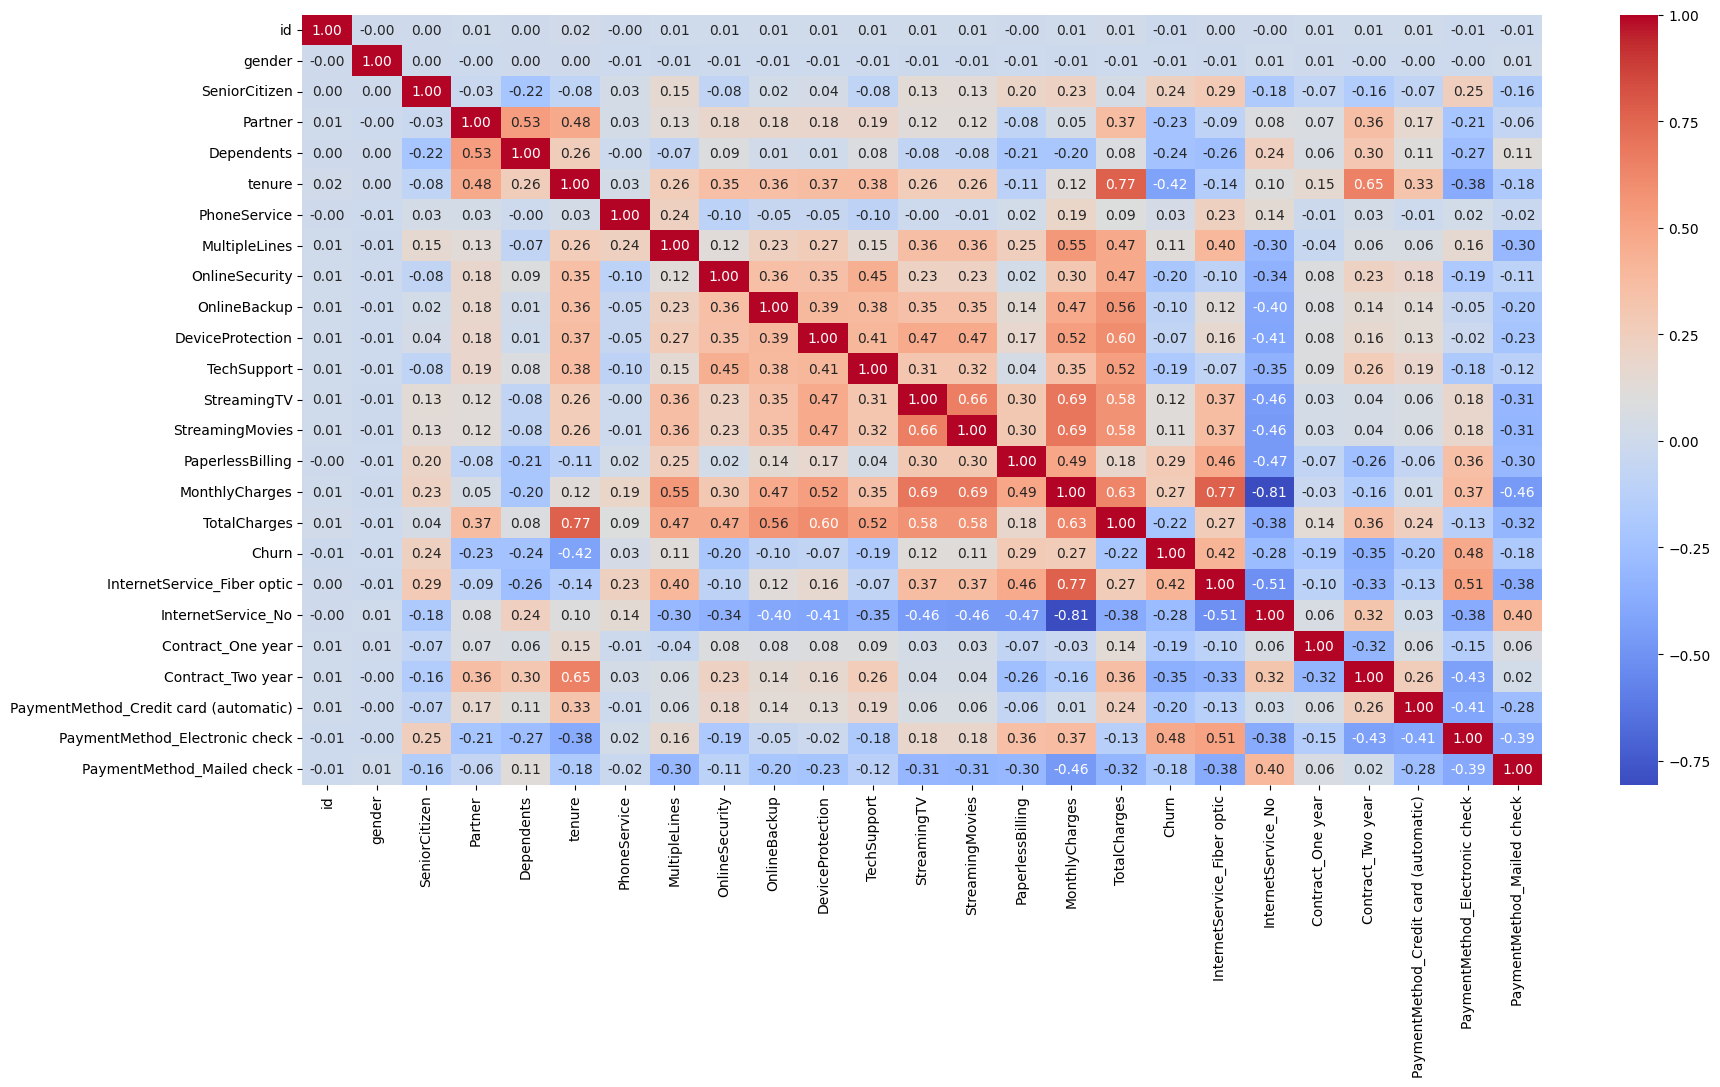

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 10))
sns.heatmap(train_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [29]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=91935/26904
)


lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=1.0,
    colsample_bytree=1.0
)


cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    verbose=0
)

models = [xgb, lgbm, cat]

x = train_encoded.drop('Churn', axis=1)
y = train_encoded['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [31]:

for model in models:
    model.fit(X_train_res, y_train_res)
    print(f'{model.__class__.__name__} Accuracy: {model.score(x_test, y_test):.4f}')

c:\Users\sumed\Desktop\ml\lab\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:06:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier Accuracy: 0.7966
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 368301, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 878
[LightGBM] [Info] Number of data points in the train set: 736602, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LGBMClassifier Accuracy: 0.8478
CatBoostClassifier Accuracy: 0.8491


In [32]:
from sklearn.metrics import classification_report
for model in models:
    y_pred = model.predict(x_test)
    print(f'{model.__class__.__name__} Classification Report:\n{classification_report(y_test, y_pred)}')

XGBClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85     92076
           1       0.53      0.90      0.66     26763

    accuracy                           0.80    118839
   macro avg       0.75      0.83      0.76    118839
weighted avg       0.86      0.80      0.81    118839

LGBMClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     92076
           1       0.65      0.71      0.68     26763

    accuracy                           0.85    118839
   macro avg       0.78      0.80      0.79    118839
weighted avg       0.85      0.85      0.85    118839

CatBoostClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     92076
           1       0.65      0.71      0.68     26763

    accuracy                           0.85    118839
   macro av

In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = { 'num_leaves': [31, 50, 70], 'max_depth': [-1, 5, 10], 'learning_rate': [0.01, 0.05], 'n_estimators': [300, 500, 800], 'min_child_samples': [20, 50, 100] }


random_search = RandomizedSearchCV(
    LGBMClassifier(),
    param_distributions=param_grid,
    n_iter=20,           # try 20–40
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 368301, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 878
[LightGBM] [Info] Number of data points in the train set: 736602, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05], 'max_depth': [-1, 5, ...], 'min_child_samples': [20, 50, ...], 'n_estimators': [300, 500, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:

In [40]:
best_lgbm = random_search.best_estimator_
y_pred = best_lgbm.predict(x_test)
print(f'Best LGBM Accuracy: {best_lgbm.score(x_test, y_test):.4f}')
print(f'Best LGBM Classification Report:\n{classification_report(y_test, y_pred)}')

Best LGBM Accuracy: 0.8349
Best LGBM Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89     92076
           1       0.61      0.77      0.68     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.81      0.78    118839
weighted avg       0.85      0.83      0.84    118839



In [41]:
y_prob = best_lgbm.predict_proba(x_test)[:, 1]

for t in [0.4, 0.45, 0.5]:
    y_pred = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.95      0.81      0.88     92076
           1       0.57      0.84      0.68     26763

    accuracy                           0.82    118839
   macro avg       0.76      0.83      0.78    118839
weighted avg       0.86      0.82      0.83    118839


Threshold: 0.45
              precision    recall  f1-score   support

           0       0.94      0.84      0.88     92076
           1       0.59      0.80      0.68     26763

    accuracy                           0.83    118839
   macro avg       0.76      0.82      0.78    118839
weighted avg       0.86      0.83      0.84    118839


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.85      0.89     92076
           1       0.61      0.77      0.68     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.81      0.78    118839
weighted avg       0.85  